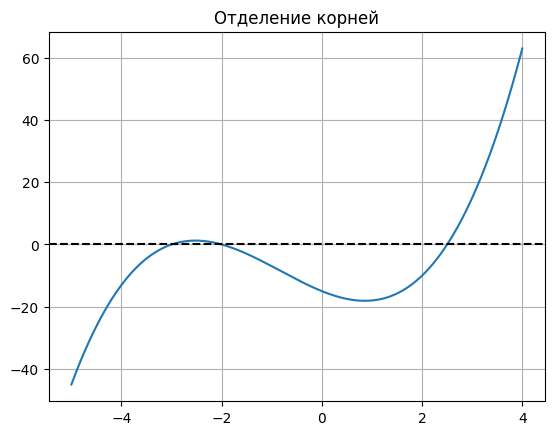

OverflowError: (34, 'Result too large')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 + 2.5*x**2 - 6.5*x - 15

def phi(x):
    return (x**3 + 2.5*x**2 - 15) / 6.5

def simple_iteration(x0, eps=1e-6):
    x_prev = x0
    while True:
        x_next = phi(x_prev)
        if abs(x_next - x_prev) < eps:
            return x_next
        x_prev = x_next

x = np.linspace(-5, 4, 400)
plt.figure(1)
plt.plot(x, f(x))
plt.axhline(0, color='black', ls='--')
plt.grid(True)
plt.title('Отделение корней')
plt.show()

roots = [simple_iteration(-4.0), simple_iteration(-1.0), simple_iteration(3.0)]
print("Корни:", roots)

plt.figure(2)
plt.plot(x, f(x))
plt.axhline(0, color='black', ls='--')
plt.plot(roots, [0,0,0], 'ro')
plt.grid(True)
plt.title('Корни уравнения')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def circuit(I):
    return I - 10/(2 + 10/(1 + I**2))

def bisect(f, a, b, eps=1e-6):
    while (b - a) > eps:
        c = (a + b)/2
        if f(a) * f(c) <= 0:
            b = c
        else:
            a = c
    return (a + b)/2

I = np.linspace(0.1, 5, 100)
plt.figure(3)
plt.plot(I, circuit(I))
plt.axhline(0, color='black', ls='--')
plt.grid(True)
plt.title('Отделение корня для тока')
plt.show()

I_root = bisect(circuit, 2.0, 3.0)
print(f"Ток: {I_root:.4f} А")

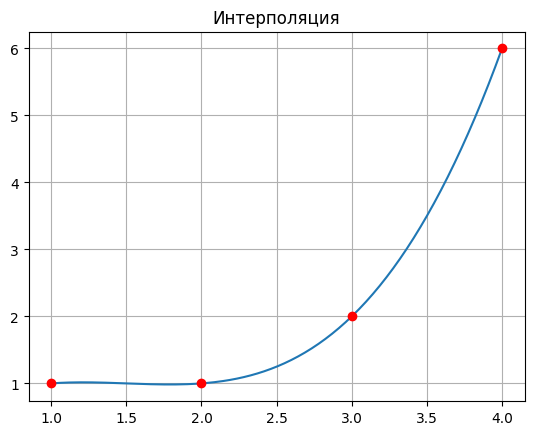

Значение при x=2.5: 1.2500


In [20]:
import numpy as np
import matplotlib.pyplot as plt

x_data = np.array([1, 2, 3, 4])
y_data = np.array([1, 1, 2, 6])

def lagrange(x, x_data, y_data):
    result = 0
    for i in range(len(x_data)):
        term = y_data[i]
        for j in range(len(x_data)):
            if j != i:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        result += term
    return result

x_smooth = np.linspace(1, 4, 200)
y_smooth = [lagrange(x, x_data, y_data) for x in x_smooth]

plt.figure(4)
plt.plot(x_smooth, y_smooth)
plt.plot(x_data, y_data, 'ro')
plt.grid(True)
plt.title('Интерполяция')
plt.show()

print(f"Значение при x=2.5: {lagrange(2.5, x_data, y_data):.4f}")